   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2
   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width
0     -0.900681     1.019004     -1.340227    -1.315444
1     -1.143017    -0.131979     -1.340227    -1.315444
2     -1.385353     0.328414     -1.397064    -1.315444
3     -1.506521     0.098217     -1.283389    -1.315444
4     -1.021849     1.249201     -1.340227    -1.315444
   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width
0     -0.900681     1.019004     -1.340227    -1.315444
1     -1.143017    -0.131979     -1.340227    -1.315444
2     -1.385353     0.328414     -1.397064    -1.315444
3     -1.506521     0.098217     -1.283389    -1.315444
4     -1.021849     1.249201     -1.340227    -1

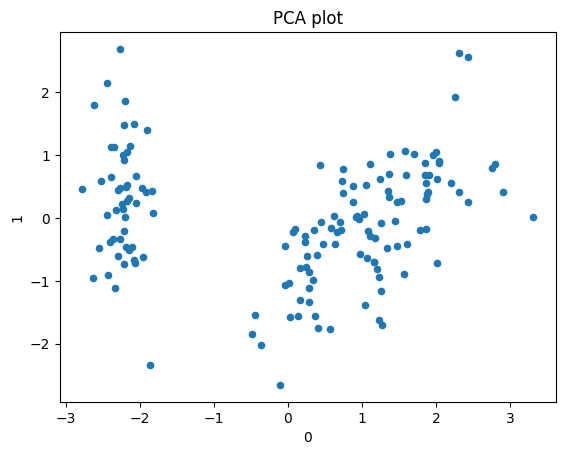

In [ ]:
#12-1
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns 

#데이터 준비
df = pd.read_csv('D:/2604340036 - 송성민/빅데이터/빅데이터/data/iris.csv')
df = df.drop('Species', axis=1)
print(df.head())

#데이처 표준화
scaler = StandardScaler()
result = scaler.fit_transform(df)
df_scaled = pd.DataFrame(result, columns = df.columns)
print(df_scaled.head())

#데이터 표준화
scaler = StandardScaler()
result = scaler.fit_transform(df)
df_scaled= pd.DataFrame(result, columns=df.columns)
print(df_scaled.head())

#차원 축소
pca = PCA(n_components=2)
transform = pca.fit_transform(df_scaled)
transform = pd.DataFrame(transform)
print(transform.head())

#시각화
transform.plot.scatter(x = 0, y = 1, title = 'PCA plot')
plt.show()

   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2 

   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width
0     -0.900681     1.019004     -1.340227    -1.315444
1     -1.143017    -0.131979     -1.340227    -1.315444
2     -1.385353     0.328414     -1.397064    -1.315444
3     -1.506521     0.098217     -1.283389    -1.315444
4     -1.021849     1.249201     -1.340227    -1.315444 

[[ 1.13597027  0.08842168  0.99615451  1.01752612]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [-0.05021989 -0.88337647  0.34773781  0.2815273 ]] 

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 2 2 2 0 2 2 2 2 2 2 2 2 0 2 2 2 2 0 2 2 2
 2 0 0 0 2 2 2 2 2

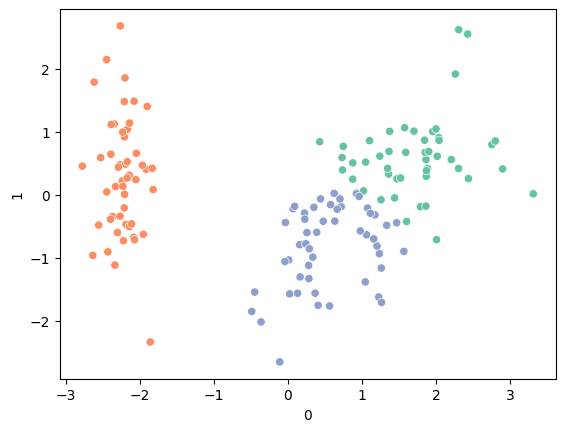

AttributeError: Line2D.set() got an unexpected keyword argument 'ylable'

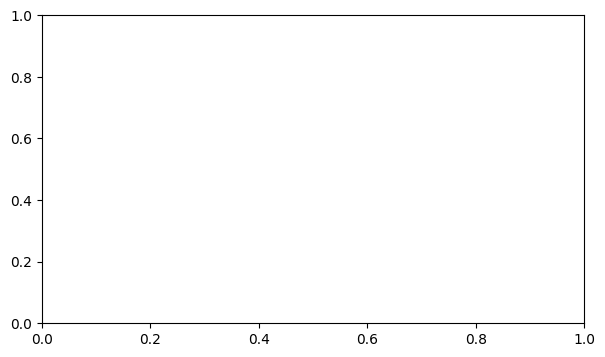

In [ ]:
#12-2
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

#데이터 준비
df = pd.read_csv("D:/2604340036 - 송성민/빅데이터/빅데이터/data/iris.csv")
df = df.drop('Species', axis = 1)
print(df.head(), '\n')

#데이처 표준화
scaler = StandardScaler()
result = scaler.fit_transform(df)
df_scaled = pd.DataFrame(result, columns = df.columns)
print(df_scaled.head(), '\n')

#군집화
model = KMeans(n_clusters = 3, n_init = 10, random_state = 123)
model.fit(df_scaled)

#군집화 결과 확인
print(model.cluster_centers_, '\n')
print(model.labels_, '\n')
print(model.inertia_, '\n')

#차원 축소
pca = PCA(n_components = 2)
transform = pca.fit_transform(df_scaled)
transform = pd.DataFrame(transform)
transform['cluster'] = model.labels_
print(transform.head(), '\n')


sns.scatterplot(data = transform,
                x = 0,  
                y = 1,
                hue = 'cluster',
                palette = 'Set2',
                legend = False)

plt.show()

ks = range(1, 10)
inertias = pd.Series([])

for k in ks:
    model = KMeans(n_clusters=k, n_init=10, random_state=123)
    model.fit(df_scaled)
    inertias.loc[k] = model.inertia_
    
plt.figure(figsize=(7,4))
inertias.plot.line(title = 'Inertias Score', 
                   xlabel = 'number of cluster, k', 
                   ylable = 'inertia')
plt.show()

In [6]:
#12-2
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier as KNC

df = pd.read_csv('D:/2604340036 - 송성민/빅데이터/빅데이터/data/PimaIndiansDiabetes.csv')
print(df.head())
df.groupby('diabetes')['diabetes'].count()

X = df.drop('diabetes', axis = 1)
y = df['diabetes']

scaler = StandardScaler()
scaler.fit(X)
result = scaler.transform(X)
X_scaled = pd.DataFrame(result, columns=X.columns)
X_scaled.head()

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=123, stratify=y)

knn = KNC(n_neighbors= 3)
knn.fit(X_train, y_train)

knn.score(X_test, y_test)

data = pd.DataFrame([[8, 182, 64, 0, 0, 23, 0.67, 32]], columns=X_test.columns)
data = scaler.transform(data)
patient = pd.DataFrame(data, columns=X_test.columns)
print(patient)

pred = knn.predict(patient)
print(pred)

pred = knn.predict(X_test)
print(pred)

   pregnant  glucose  pressure  triceps  insulin  mass  pedigree  age diabetes
0         6      148        72       35        0  33.6     0.627   50      pos
1         1       85        66       29        0  26.6     0.351   31      neg
2         8      183        64        0        0  23.3     0.672   32      pos
3         1       89        66       23       94  28.1     0.167   21      neg
4         0      137        40       35      168  43.1     2.288   33      pos
   pregnant   glucose  pressure   triceps   insulin      mass  pedigree  \
0   1.23388  1.912427 -0.263941 -1.288212 -0.692891 -1.141331  0.598357   

        age  
0 -0.105584  
['pos']
['neg' 'neg' 'neg' 'neg' 'neg' 'neg' 'neg' 'pos' 'neg' 'pos' 'pos' 'neg'
 'neg' 'neg' 'neg' 'pos' 'neg' 'neg' 'neg' 'neg' 'pos' 'neg' 'pos' 'pos'
 'neg' 'pos' 'neg' 'neg' 'neg' 'pos' 'neg' 'neg' 'neg' 'neg' 'pos' 'neg'
 'neg' 'neg' 'pos' 'pos' 'neg' 'neg' 'neg' 'neg' 'neg' 'neg' 'neg' 'neg'
 'neg' 'neg' 'neg' 'neg' 'neg' 'neg' 'pos' 'neg

                   job  education  income  women  prestige  census  type
0   gov.administrators      13.11   12351  11.16      68.8    1113  prof
1     general.managers      12.26   25879   4.02      69.1    1130  prof
2          accountants      12.77    9271  15.70      63.4    1171  prof
3  purchasing.officers      11.42    8865   9.11      56.8    1175  prof
4             chemists      14.62    8403  11.68      73.5    2111  prof


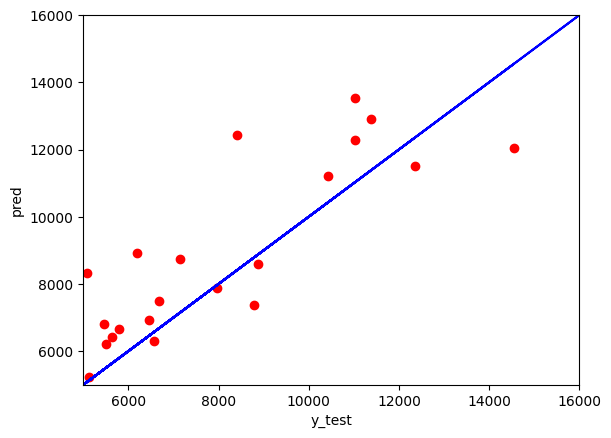

   education  women  prestige
0         12     10        80
[13007.9197067]


In [7]:
# 12-5

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression as LR
from sklearn.metrics import mean_absolute_error as MAE
import matplotlib.pyplot as plt

df = pd.read_csv('D:/2604340036 - 송성민/빅데이터/빅데이터/data/prestige.csv')
print(df.head())

X = df[['education', 'women', 'prestige']]
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=123)

model = LR()
model.fit(X_train, y_train)

model.coef_
model.fit(X_train, y_train)

model.coef_
model.intercept_

pred = model.predict(X_test)
MAE(y_test, pred)

plt.scatter(y_test, pred, color='red')
plt.xlim([5000, 16000])
plt.ylim([5000, 16000])
plt.xlabel('y_test')
plt.ylabel('pred')
plt.plot(y_test, y_test, color = 'blue')
plt.show()

job = pd.DataFrame([[12, 10, 80]], columns=X_test.columns)
print(job)
pred = model.predict(job)
print(pred)